Conditional Edges in graph

In [13]:
%pip install --quiet -U langgraph>=1.0.0


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from IPython.display import Image, display
from typing import  List,  TypedDict, Annotated,operator, Literal
from langgraph.graph import END, START, StateGraph

In [15]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [22]:
def node_a(state: State) -> State:
    print(f"Adding 'A': {state['nlist']}")
    return(State(nlist = ['c']))
def node_b(state: State) -> State:
    print(f"Adding 'B': {state['nlist']}")
    return(State(nlist = ['B']))
def node_c(state: State) -> State:
    print(f"Adding 'C': {state['nlist']}")
    return(State(nlist = ['C']))



In [23]:
def conditional_edge(state: State) -> Literal['b', 'c']:
    slected_node = state['nlist'][-1]  # Get the last added node
    if slected_node == 'b':
        return 'b'
    elif slected_node == 'c':
        return 'c'
    else:
       return END

In [24]:
builder = StateGraph(State)

builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

builder.add_edge(START, "a")
#builder.add_edge("a", "b")
#builder.add_edge("a", "c")
builder.add_conditional_edges("a", conditional_edge)
builder.add_edge("b", END)
builder.add_edge("c", END)
graph = builder.compile()


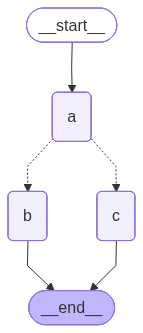

In [25]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
user_prompt = State(
    nlist = ["initial state"]
)
graph.invoke(user_prompt)

Adding 'A': ['initial state']
Adding 'C': ['initial state', 'c']


{'nlist': ['initial state', 'c', 'C']}